# **HW 1: Reading and analyzing data using Python**
##**Due Date: 9/1**

The goal of this homework assignment is to reinforce the Python programming concepts and constructs that we've covered in class by ensuring that you can read, manipulate, and analyze data using Python, and document your work using a Jupyter notebook. This is a central part of any data analytics workflow; you can't use data you can't access!

In [1]:
# please run this the first time to install packages!
!pip install numpy
!pip install pandas
!pip install ydata-profiling
!pip install ipywidgets
!pip install openpyxl
!pip install numpy
!pip install matplotlib

## **Part 1: Basic dataset reading, querying, plotting, etc.**

The problems in this first part are taken directly from a PACE Python 101 Course on using Python for data analytics, developed by Dr. Michael Weiner. If you feel that you need more practice or want to reinforce what you're doing in these homework problems, I'd highly recommend taking the PACE Python 101 short courses.

### *How* do I use Python to analyze my data?
Let's get started!
First, we'll need an example data set. Let's look at CO<sub>2</sub> emissions data from the World Bank.

The file contains CO<sub>2</sub> emissions (kg per PPP $ of GDP) for 1990-2014, by country. This will let us compare emissions to economic growth.

This data is available as a **csv** (comma-separated values) file, a common file format for tables of data.

It has already been cleaned from the original source and turned into a straightforward csv file that will be easy for us to load. In some cases, this data cleaning step may be complex and require its own process, beyond the scope of this workshop.

To load a csv file, we can use `genfromtxt`, a function in the **numpy** library.

### What is NumPy?
- NumPy is a widely-popular Python library for scientific computing. It works with arrays and contains numerous functions for mathematical operations (e.g., linear algebra).

- The manual is available at https://docs.scipy.org/doc/numpy/index.html.

- With NumPy, much of Matlab's functionality is available through Python (for free!). If you are a Matlab user, you may find this website useful for transitioning to NumPy (https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html).

- Load numpy by importing its library. It is common to abbreviate it as np for calling:
```Python
    import numpy as np
```

In [2]:
# load numpy
import numpy as np

### Now we can load the csv file's data into an array. What is an array?
- A key feature of NumPy
- Grid of same-type values (one or more dimensions)
    - or even zero-dimensions for an empty array []
    - Think of a 2D array as a matrix.
- Zero-indexed, so `a[0]` is the 1st element of array a
    - We can also count backwards, so `a[-1]` is the last element, and `a[-2]` is the penultimate element.
- Like Python's built-in lists, but better!
    - more efficient in memory
    - access to numpy methods

In [3]:
# load csv into an array named co2data
# This will create a variable named co2data. Notice that we don't need to declare it first.
# Notice that we use the delimiter keyword to specify that values are separated by commas.
co2data = np.genfromtxt("co2py.csv", delimiter=",")

# Shouldn't we use pandas DataFrame instead of numpy array?????? Feel like that's the obvious
# choice for a csv.

# the first column of the data is country names, not numbers, so they all show up as NaN
# (not a number)
# let's delete column 0 (the first column)
# the first row is the year for the emissions data (1990-2014), so let's strip that out as well
# the first index is the row number, and the second index is the column number
# "1:"" means to select rows/columns 1 (that's the second row/column) to the end
co2data = co2data[1:, 1:]

# again, if we were using a DataFrame we could have used co2data.drop(co2data.columns[0], axis=1)

In [4]:
# We also might want the country names later. Let's save them in an array also.
# We'll specify "dtype=str" to say that we want to create an array of strings (text), not numbers
# The default dtype is float, meaning a floating-point number, not an integer or string.
countries = np.genfromtxt("co2py.csv", delimiter=",", usecols=0, dtype=str)

# strip the first row here too, so the arrays match
# this is only 1D, so we specify only 1 dimension of range to keep
countries = countries[1:]

### How can I see my data, now that I've loaded it?
Use the `print` command to print out a variable (or something else).
In Python 3, put what you want to print in parentheses.

Since `co2data` is a long array, the notebook will show us the beginning and end with an ellipsis between.

To see a specific row, e.g. row 40, use `co2data[40]`. For the fourth element of that row, use `co2data[40][4]` or `co2data[40,4]`.

In [5]:
print(co2data)

[[       nan        nan        nan ... 0.19103148 0.1655359  0.15491035]
 [0.65821926 0.68734342 0.42490223 ... 0.16082721 0.1654725  0.17574495]
 [0.4471523  0.44960436 0.4377632  ... 0.25795182 0.25517266 0.26091423]
 ...
 [0.36864888 0.32188839 0.31435807 ... 0.19384761 0.24820782 0.21727737]
 [0.20049358 0.19167837 0.19389184 ... 0.06974461 0.07039501 0.07510171]
 [0.81954365 0.76614884 0.87779939 ... 0.23442166 0.33845507 0.33403748]]


The dataset turns out to be missing data from some years, which is showing up here as 'nan' ('not a number')

'nan' can also indicate division by zero in some situations

In [6]:
co2data[40, 4]

np.float64(0.409473521)

How big is co2data? We can use the shape function of NumPy to find its dimensions:

In [7]:
np.shape(co2data)

(217, 25)

## *Hands-On Exercise 1*
This first hands-on exercise will repeat a bit of what we just learned. The upcoming exercises will be more exciting!

Use the cells below to answer the following questions:

1. Load the data set and store it in arrays
2. Print line number 100 (i.e., the 101st country).
3. Which country's data are you viewing?
4. Is it complete? If not, what's missing? Which years?
    - Bonus Question: Why would those years be missing? (not a Python exercise)

In [8]:
# 1.
# Should use DataFrame instead, but sure
co2_data = np.genfromtxt("co2py.csv", delimiter=",")
country_titles = np.genfromtxt("co2py.csv", delimiter=",", usecols=0, dtype=str)
years = np.genfromtxt("co2py.csv", delimiter=",", max_rows=1, dtype=int)

co2_data = co2_data[1:, 1:]  # delete years and country names
years = years[1:]  # vertex is just -1
country_titles = country_titles[1:]  # vertex is just -1

In [9]:
# 2.
print(co2_data[100])

[       nan        nan 2.12382032 1.89753901 1.95341674 1.763027
 1.441332   1.27434888 1.26335928 1.10950319 1.00200875 0.96446679
 0.87706864 0.83773252 0.90574656 0.82049967 0.78150259 0.8066736
 0.8020334  0.72075495 0.77356948 0.73536426 0.64572602 0.64764063
 0.57627012]


In [10]:
# 3.
print(country_titles[100])

Kazakhstan


In [11]:
# 4.
# we are missing 1990 and 1991
print(years)

[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014]


In [12]:
# 4.b.
# Khazakstan did not exist as an independent nation yet during those years

Let's say I want to find the data for the US.

Wouldn't it be nice if there were an easy way to find which row goes with which country? There is! But first, we need to introduce the concept of a **dictionary**.


### Dicts
a Python data structure that stores **key:value** pairs
- comma-separated list of key:value pairs within braces `my dict={'key 1':value1,'key2':value2}`
- `mydict=dict()` then `mydict['key1']=value1`, then `mydict['key2']=value2`
- search based on key, rather than index
    - This means we can search by country name (a string, not a number)!
- unordered (efficient for searches, implemented as a hash table)


To build this dictionary, we need to go through each line of the `countries` array one-by-one and create a dictionary entry with an array of the country's annual data. This type of behavior is the purpose of a **for loop**.

### Loops
- can iterate over items of any sequence and do repeated actions
- for loops:
    - syntax (especially second-line indent):
    ```Python
        for iterating_variable in sequence:
            statements
    ```
    - steps:
        - iterating_variable is the items in the sequence
        - colon at the end of the line tells Python that everything **nested** below is part of the loop
        - statements in the loop must be indented
- while loops also exist, for cases where a step is repeated until the condition changes


In [13]:
# Let's use a for loop to create a dictionary of key-value pairs of country-data

# First, create an empty dictionary that we can fill
co2_dict: dict[str, float] = dict()

# Now, let's use a for loop

# i is the iterator, and we actually use it in each step
# after 'in', we have to give a list of the values over which i should iterate
# I've employed the range function, which will produce a sequence of integers from 0 up to
# the argument (excluding it)
# len finds the length of an array

for i in range(len(countries)):
    co2_dict[countries[i]] = co2data[i]

In [14]:
# Let's find the data for Afghanistan. Now, I don't need to know the line number, and I can do
# everything in one line:
print(co2_dict["Afghanistan"])

[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 0.05643612 0.05683853 0.04335998 0.05283911 0.06051272 0.07132976
 0.12455352 0.16388575 0.17710488 0.24983588 0.19103148 0.1655359
 0.15491035]


Now I have all of these variables. What if I forget what they are?
The python function `type` will tell you what data structure is stored in a variable.

In [15]:
print(type(co2data))
print(type(co2_dict))

<class 'numpy.ndarray'>
<class 'dict'>


## *Hands-On Exercise 2*
1. Use a for loop to print out the name of each country in the list, followed by its emissions data from 1990 (the first year in the data set).

In [16]:
for i in range(len(co2_data)):
    print(f"country - {countries[i]}, 1990 - {co2_data[i, 0]}")

country - Afghanistan, 1990 - nan
country - Albania, 1990 - 0.658219258
country - Algeria, 1990 - 0.447152303
country - American Samoa, 1990 - nan
country - Andorra, 1990 - nan
country - Angola, 1990 - 0.139737171
country - Antigua and Barbuda, 1990 - 0.398259463
country - Argentina, 1990 - 0.465866914
country - Armenia, 1990 - nan
country - Aruba, 1990 - 1.09432735
country - Australia, 1990 - 0.891705602
country - Austria, 1990 - 0.386437896
country - Azerbaijan, 1990 - nan
country - Bahamas  The, 1990 - 0.378415514
country - Bahrain, 1990 - 1.099750888
country - Bangladesh, 1990 - 0.175025148
country - Barbados, 1990 - 0.449288859
country - Belarus, 1990 - nan
country - Belgium, 1990 - 0.567176985
country - Belize, 1990 - 0.500605988
country - Benin, 1990 - 0.149770628
country - Bermuda, 1990 - 0.321785008
country - Bhutan, 1990 - 0.158312532
country - Bolivia, 1990 - 0.349042385
country - Bosnia and Herzegovina, 1990 - nan
country - Botswana, 1990 - 0.380697978
country - Brazil, 199

We're going to do some analysis on this, but I want to get a sense of the data first, so let's graph it!

### Graphing with matplotlib
- Matplotlib is a powerful Python library for plotting.
- We'll only see a small portion of it here. Visit matplotlib.org for more examples and documentation.


In [17]:
# load pyplot from Matplotlib. It's usually abbreviated as plt.
import matplotlib.pyplot as plt

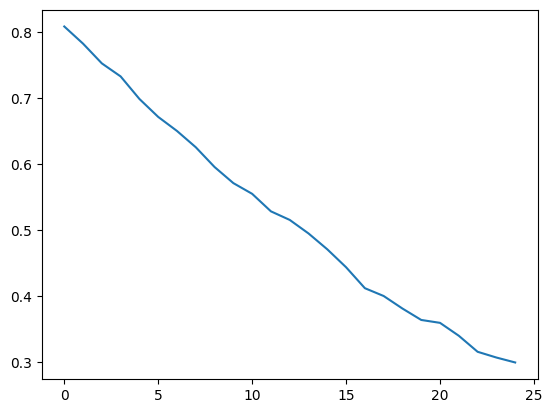

In [18]:
# Here's the simplest possible plot - US carbon emissions, 1990-2014
# we're only giving the y-axis here, with the x-axis implied
plt.plot(co2_dict["United States"])

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10786/758205507.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Year $\mu$')


Text(0, 0.5, 'CO2 emissions (kg per PPP $ of GDP)')

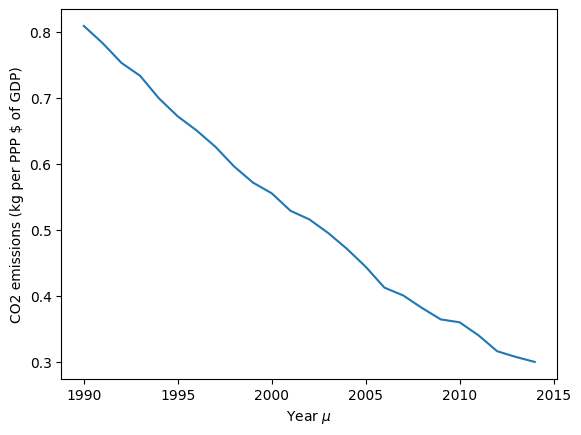

In [19]:
# It would be nice if the x-axis were accurate with the year number
# now, we're going to use range with start, stop, and step size arguments
plt.plot(range(1990, 2015, 1), co2_dict["United States"])

# Let's label the axes as well
plt.xlabel("Year $\mu$")
plt.ylabel("CO2 emissions (kg per PPP $ of GDP)")

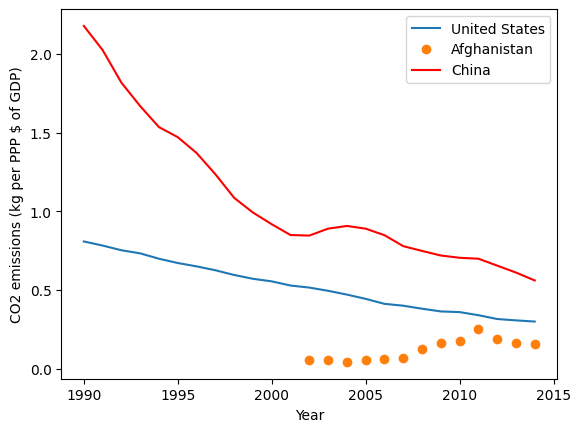

In [20]:
# Let's plot three countries on the same axes
# I can specify the color & shape of the markers after the data
plt.plot(range(1990, 2015, 1), co2_dict["United States"])  # the default is to plot a line
plt.plot(range(1990, 2015, 1), co2_dict["Afghanistan"], "o")  # o means to plot circles
plt.plot(range(1990, 2015, 1), co2_dict["China"], "r")  # 'r' means to plot in red

# Let's label the axes as well
plt.xlabel("Year")
plt.ylabel("CO2 emissions (kg per PPP $ of GDP)")

# and include a legend, with the labels in the order in which we generated the plots
plt.legend(["United States", "Afghanistan", "China"])

What if we want to save the graph to file instead of seeing it on the screen? If you run your Python code in batch mode, rather than interactively (as in a Jupyter notebook), saving a graph to file will be the only way to see it.

Use `plt.savefig` after specifying the plot you want.

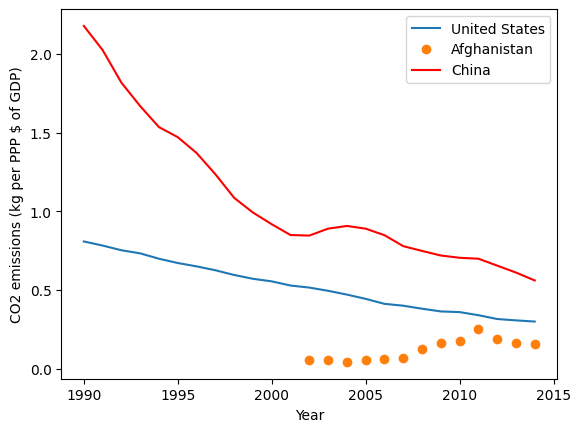

In [21]:
# Again, let's plot three countries on the same axes
# I can specify the color & shape of the markers after the data
plt.plot(range(1990, 2015, 1), co2_dict["United States"])  # the default is to plot a line
plt.plot(range(1990, 2015, 1), co2_dict["Afghanistan"], "o")  # o means to plot circles
plt.plot(range(1990, 2015, 1), co2_dict["China"], "r")  # 'r' means to plot in red

# Let's label the axes as well
plt.xlabel("Year")
plt.ylabel("CO2 emissions (kg per PPP $ of GDP)")

# and include a legend, with the labels in the order in which we generated the plots
plt.legend(["United States", "Afghanistan", "China"])
plt.savefig("3countries.pdf", format="pdf")  # to save to file - filename and format

### There's much, much more to matplotlib than this. Check it out later!

## *Hands-On Exercise 3*
1. Plot the data for Ukraine for all years as red stars.
2. Plot the data for Japan for all years as a green line on the same plot.
3. Label your axes and add a legend.

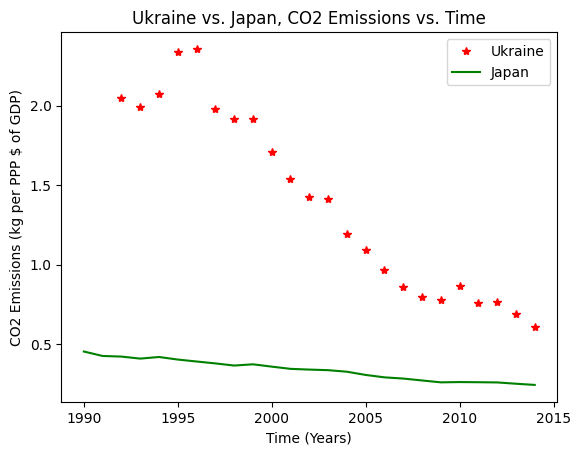

In [22]:
# more correct/safer to make an instance object
fig, ax = plt.subplots()

ax.plot(
    range(1990, 2015, 1),
    co2_dict["Ukraine"],
    label="Ukraine",
    color="red",
    linestyle="",
    marker="*",
)
ax.plot(
    range(1990, 2015, 1),
    co2_dict["Japan"],
    label="Japan",
    color="green",
)

ax.set(
    title="Ukraine vs. Japan, CO2 Emissions vs. Time",
    ylabel="CO2 Emissions (kg per PPP $ of GDP)",
    xlabel="Time (Years)",
)
ax.legend()

fig.savefig("2countries.jpg", format="jpg")

What if we want to compare two countries' data? NumPy can do elementwise operations given two arrays.
So, what fraction of Chinese emissions per GDP is the American value, for each year?

NumPy has many operations built-in, but we don't have time to discuss those today. For example, np.sqrt(array1) would return an array of the same dimensions as array1, but every element would be the square root of the corresponding element in array1. There are also many linear algebra functions, such as dot products.

In [23]:
ratio = co2_dict["United States"] / co2_dict["China"]
# performs an elementwise division between 2 arrays of the same size and returns an array

What if I want to save this data for later? Let's save it to file.
If you run Python in a batch setting, this is the way to save & view the output.

### File Output in NumPy
There are many functions in both Python and NumPy for saving variables to file. Here is one.

In [24]:
# a function of an array is "tofile"
# we specify the destination file name and the separator between elements of the array
# '\n' is a newline character, to put each element on its own line
ratio.tofile("ratio.out", sep="\n")

In [25]:
# Let's look at that file with the Linux cat command. We can access the command line in Jupyter
# with %.
%cat ratio.out

0.3712972979687503
0.3865386457271649
0.4141569898802243
0.4393542928945654
0.45530177055867666
0.45655316824839315
0.4744605251675029
0.5062675828365465
0.5486282307597167
0.5758029026037492
0.6046582954592503
0.6224007992235571
0.6096315333365723
0.5563960800179525
0.5193141092632613
0.4988869334753374
0.4859008605583885
0.5141144250487938
0.5096067987409276
0.506271855705424
0.5103782850709202
0.486684743492658
0.48224698539008937
0.5027680522383945
0.534497281768634

### Additional Resources
- Take the PACE Intro to Python courses: https://gatech.service-now.com/home?id=kb_article_view&sysparm_article=KB0042286
- An introduction with some more details, including on NumPy, by Kevin Manalo: https://github.com/marcc-hpc/python3-tutorial/blob/master/python3-tutorial.ipynb
- Software Carpentry "Programming with Python" (free to public): http://swcarpentry.github.io/python-novice-inflammation/
    - very extensive introduction to Python in 10 parts, with an emphasis on data analysis

## **Part 2: Using pandas-profiling to run data reports**
#### ***NOTE: instructions to configure Pandas-profiling are at the end of the notebook; please scroll down to read***

Despite their age, Excel and CSV (comma-separated value) formatted files are still very, very common. In this problem, you will write a data parsers for analyzing data contained within csv files using pandas-profiling, a powerful data reporting package.

In [26]:
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport

/tmp/ipykernel_10786/3299133335.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


## *Problem 1. Reading a simple CSV*
Add code to the function "read_csv" to correctly read the data from the CSV file and return a pandas data frame

In [ ]:
# when you run this cell, a report will be generated that tells you about the
# values of the variables present in this table.

# To "collapse" a cell in a jupyter notebook, click on the left margin just below "Out[#]:"; to
# expand, click again.
simpleCSV = "iris_dataset.csv"

df = pd.read_csv(simpleCSV)

profile = ProfileReport(df, title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 21982.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 2. Reading a more realistic CSV

Despite the name, it is very common to find a "CSV" file where the values aren't separated by commas, or that have information (often at the top of the file, called a "header"). look up in the pnadas documentation how to read a file like this (also take a look at the file to see what it looks like).

In [ ]:
grainsCSV = "Grains.csv"

# File is tab-separated and there are only 47 headers, while there are 48 tabs (trailing tab)
# So we need to skip the last tab that would be just an empty data point (data comes after a tab)
df = pd.read_csv(grainsCSV, sep="\t", usecols=range(47))

# Needed to use interactions=None and pool_size=4 as normal was taking more than 10 minutes
profile = ProfileReport(df, title="Profiling Report", interactions=None, pool_size=4)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 47/47 [00:01<00:00, 43.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 2 Questions

Using markdown cells below, answer the following question by examining the report that you just created:

1. Is this dataset ready to be used for machine learning modeling? Why or why not? (is the dataset well populated? are parts of it well populated and others not? of the parts that are populated, are all of the data ammenable to machine learning? if not, why not? How does it compare with the previous dataset?)

# ANSWER

The Grains dataset is not ready for machine learning modelling without a lot of preprocessing and more information/clarification on what the objective is. 

It has 516 observations and 47 columns; all 47 columns have values in every row, so it appears well populated.

But, GrainID, for example, is an identifier, rather than a real input feature - should probably be removed. PhaseNr has the same value (1) for all observations, so it provides no information. If it were a classification label, a classifier wouldn't be able to be trained, as the dataset only contains 1 class. Other than that, the dataset has no clear target variable, unlike the Iris dataset.

Other columns, like Eul10, 11, and 12 are all zeroes in more than half of the observations. It also has redundant features, like eFab12 and 21, and eFab13 and 31, which are identical - guessing they are symmetric tensors, but they should not be treated as independent degrees of freedom. They can increase complexity and even overfitting or multicollinearity.

Also, they have largely different scales, so feature scalling is definitely required. And a lot of clusters/outliers can be seen from the population plots - not necessarily bad, but we need more information on the physical system.

The Iris dataset has 4 clearly defined input features, a clearly defined 3 class target, no missing values, and good coverage of all 3 targets. Grains contains redundant and constant variables, no clear target, and thus no information on coverage, etc. can be inferred.

### Problem 3. Reading an Excel file

Apart from computers themselves, Excel is probably the most widely used engineering tool on the planet. You will not get away from reading and parsing Excel files. These can be particularly tricky as people will add descriptions, place multiple tables in a single worksheet, etc. Too many variants exist to test all the ways people use-and-abuse Excel. Please read in an excel file using pandas.

In [29]:
excelFilename = "3d-printing.xlsx"

In [31]:
excelFilename = "3d-printing.xlsx"

df = pd.read_excel(excelFilename, sheet_name=None)  # sheet_name=None reads all sheets into a dict

print(f"Worksheets: {list(df.keys())}")

Worksheets: ['build', 'mechanical', 'porosity']


In [32]:
# if you want to explore the data in one of these sheets, set the worksheet name and use
# pandas_profiling
worksheetName = "build"
profile = ProfileReport(df[worksheetName].describe(), title="Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 7256.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Problem 3 Questions

Using markdown cells below, answer the following question by examining the report that you just created:

1. Is this dataset ready to be used for machine learning modeling? Why or why not? (is the dataset well populated? are parts of if well populated and others not? of the parts that are populated, are all of the data ammenable to machine learning? if not, why not? How does it compare with the previous dataset?)

# ANSWER

This dataset is also not ready and needs substantial preparation and additional data. 

It has build, mechanical and porosity sheets - these must first be joined using the name and parent name so that printing conditions can be connected to the material properties.

The build sheet only contains 4 builds. Most potential input variables have no variation - all builds use the same composition, hatch spacing and spot size; only laser power and speed vary and cover narrow ranges. So a model couldn't learn the effect of the constant variables and would have limited coverage of the lasers.

Mechanical sheet has 16 mesaurements of modulus and yield strength, but they are replicated mesaurements for only four underlying builds. They help measure experiment variability, but don't provide 16 independent combinations of printing params. Four building conditions is not enough for a meaningful training and testing split.


### Extra Credit

These examples gave you practice reading data from local files, but more and more data is becoming available on the web. You access this through HTTP, FTP, and a variety of other approaches.

#1 If you want more of a challenge, develop a parser for the HTML in **matweb-search-results.html**.

In [5]:
import pandas as pd
from bs4 import BeautifulSoup
from pydantic import BaseModel, Field

"""
Inside each table row (<tr>), there are the cells (<td>):
First table row is headers, so we need to skip
href of each row has the link and material name
then class property cell Modulus
then conditional formatting cell
then class property cell Tensile Strength
then conditional formatting cell
then class property cell Hardness
then conditional formatting cell
"""


class Material(BaseModel):
    """
    Table is done structured like so:
    - Material Name,
    - Modulus (Group) (GPa),
    - Tensile Strength Yield (MPa),
    - Hardness Vickers

    A lot of number data is ranged,
    so variables have to be str (not int).
    Could decide on averaging later.
    """

    name: str = Field(description="Name of the material.")
    modulus_gpa: str = Field(description="Stress / strain.")
    tensile_strength: str = Field(description="Max stress material can withstand before failing.")
    hardness_vickers: str = Field(description="Resistance to localized plastic deformation.")


materials_list: list[Material] = []  # list to convert to df
matweb_seatch_html = "matweb-search-results.html"

# Open the file as read, use utf-8 as ascii could error - utf-8 is an extension of ascii
with open(matweb_seatch_html, encoding="utf-8") as file:
    # BeautifulSoup transforms html into a structured "parse tree", and use pythonic syntax like
    # soup.title, soup.body.p or methods like find_all() to filter names, attributes, CSS classes
    soup = BeautifulSoup(file, features="html.parser")

# get the table that has the metadata
results_table = soup.find(name="table", id="tblResults")

# iterate over table, extracting each piece of information
for row in results_table.find_all("tr"):
    # find all cells of class=propcell - contain Modulus, etc.
    metadata = row.find_all("td", class_="propcell")
    material_name = row.find("a")  # material name is anchor tag

    if len(metadata) != 3:
        # not a metadata row
        continue

    # build object (cast number texts to int)
    material = Material(
        name=material_name.get_text(separator=" ", strip=True),
        modulus_gpa=metadata[0].get_text(separator=" ", strip=True),
        tensile_strength=metadata[1].get_text(
            separator=" ",
            strip=True,
        ),
        hardness_vickers=metadata[2].get_text(
            separator=" ",
            strip=True,
        ),
    )

    materials_list.append(material)

df = pd.DataFrame([material.model_dump() for material in materials_list])

print(df.head())
print(f"Parsed {len(df)} materials")

                   name modulus_gpa tensile_strength hardness_vickers
0   Calcium, Ca; Rolled        23.4             84.8             17.0
1            Cerium, Ce        41.4             91.0             24.0
2            Cobalt, Co         211              225              253
3  Copper, Cu; Annealed         110             33.3             50.0
4        Dysprosium, Dy        61.4              225             44.0
Parsed 200 materials
